In [1]:
from composer import *
from bs4 import BeautifulSoup
import requests
import re
import networkx as nx
import spacy
import numpy as np
import math
import time
import pickle
import json
from ipysigma import Sigma

## NLP pour identifier des influences directes via les notices biographiques

In [2]:
"""cette cellule permet de retrouver tous les noms de compositeurs cités dans l'article wikipedia du compositeur d'intérêt et d'en dresser la liste dans un dictionnaire dont les clés sont les id des compositeurs en question"""

def get_person_entities(text):
    nlp = spacy.load("en_core_web_sm")
    doc = nlp(text)
    L=[]
    for ent in doc.ents:
        if ent.label_=='PERSON':
            #print(ent.text, ent.start_char, ent.end_char, ent.label_)
            L.append(ent.text)
    #print(L)
    return L
    
            
def get_wikipedia_page_metadata(name):
    language_code = 'en'
    search_query = name
    number_of_results = 1
    """headers = {
      # 'Authorization': 'Bearer ACCESS_TOKEN',
      'User-Agent': 'APP_NAME (EMAIL_OR_CONTACT_PAGE)'
    }"""
    base_url = 'https://api.wikimedia.org/core/v1/wikipedia/'
    endpoint = '/search/page'
    url = base_url + language_code + endpoint
    parameters = {'q': search_query, 'limit': number_of_results}
    response = requests.get(url, params=parameters)
    dico_response = json.loads(response.text)
    for page in dico_response['pages']:
      display_title = page['title']
      article_url = 'https://' + language_code + '.wikipedia.org/wiki/' + page['key']
      try:
        article_description = page['description']
      except:
        article_description = 'a Wikipedia article'
      try:
        thumbnail_url = 'https:' + page['thumbnail']['url']
      except:
        thumbnail_url = 'https://upload.wikimedia.org/wikipedia/commons/thumb/8/80/Wikipedia-logo-v2.svg/200px-Wikipedia-logo-v2.svg.png'
        

def get_wikipedia_page_text_with_api(title):
    endpoint = "https://en.wikipedia.org/w/api.php"
    params = {
        'action': 'parse',
        'page': title,
        'format': 'json',
        'prop': 'text',
    }

    response = requests.get(endpoint, params=params)
    data = response.json()

    if 'parse' in data:
        html_content = data['parse']['text']['*']
        soup = BeautifulSoup(html_content, 'html.parser')
        text = soup.get_text()
        return text
    else:
        return "Page not found or error occurred"
    
def get_wikipedia_page_text(name,language="en"):
    url = f"https://{language}.wikipedia.org/w/index.php?search={name}"
    page = requests.get(url)
    soup = BeautifulSoup(page.content, "html.parser")
    text=soup.get_text()
    if language =="en" and name+" - Wikipedia" in text:
        return get_wikipedia_page_text(name+" (composer)")
    elif language=="fr" and name+" - Wikipédia" in text:
        return get_wikipedia_page_text(naem+" (compositeur)")
    return text


## filtre pour ne conserver que les noms de compositeurs

In [3]:
def composer_filter_by_dict(list_of_names, dico):
    """filtre les noms qui sont ceux de compositeurs à partir d'un dictionnaire de compositeurs, évite d'avoir à rechercher dans wikidata à chaque fois donc plus rapide mais moins robuste, à compléter peut-être avec le TD qui utilisait des Trie"""
    list_of_names = list(filter(lambda x: x.strip() in dico, list_of_names))
    return list_of_names

#composer_filter_by_dict(["Richard Wagner","Bach","Mozart"],{"Richard Wagner":(1813,1883),"Johann Sebastian Bach":(1685,1750)})
        
def composer_filter(list_of_names):
    compo_dico={}
    for n in list_of_names:
        c_id = find_id(n)
        if c_id not in compo_dico:
            c = is_composer(c_id,n)
            #print(is_composer(n))
            if c is not None :
                compo_dico[c_id]=c
                print(n,"is a composer")
    return compo_dico

#compo_dico=composer_filter(["Bach","Beethoven","Wagner"])
#print(compo_dico)


In [4]:
def find_compositional_influences(name,fr=False):#problème : l'algo saute souvent Beethoven, y compris chez Wagner
    content = get_wikipedia_page_text(name)
    if fr:
        content+=get_wikipedia_page_text(name,"fr")
    persons = get_person_entities(content)
    return(composer_filter(persons))

def build_list_of_influences(enum_of_composers,french=False):
    list_of_influ_dict=[]
    for composer in enum_of_composers:
        list_of_influ_dict.append(find_compositional_influences(composer,fr=french))
    return list_of_influ_dict

#compos = ["André-Ernest-Modeste Grétry","Ernest Chausson","Gabriel Dupont","Paul le Flem"]
#compos = ["Franz Lachner","Jean Cras"]
#compos = ["Henri Duparc"]

#list_of_dico=build_list_of_influences(compos,True)
#print(list_of_dico)

In [5]:
"""essayons de qualifier les relations d'influence entre compositeurs plus précisément qu'avec la seule présence de l'un dans la page wikipedia de l'autre"""
"""compléter avec les influences - même peu nombreuses - spécifiées dans wikidata"""
"""penser à prévoir le cas d'un compositeur encore vivant"""
def orienting_with_dates_sparql(list_of_dico,influences={}):
    """returning an adjacency list from the dict of composers appearing in the wiki notice of the first one in the dict; orienting the influence relations when no doubt exists because of birth-death dates"""
    sparql_endpoint = "https://query.wikidata.org/sparql"
    for dico in list_of_dico:
        cpt=0
        for c in dico:
            #if c.birth is None or c.death is None:#à améliorer
            time.sleep(1)  # 0.5s between requests
            query = f"""
                    SELECT ?birth ?death WHERE {{
                        wd:{c} wdt:P569 ?birth.
                        wd:{c} wdt:P570 ?death.
                    }}
                    """
                
            if cpt>0:#the rest of the dict are the composers who may have or have been influenced our musician of interest "compo"
                response = requests.get(sparql_endpoint, params={'query': query, 'format': 'json'})
                print("Status Code:", response.status_code)
                #print("Response Text:", response.text)
                dates_dict = response.json()
                bindings = dates_dict.get("results", {}).get("bindings", [])
                if bindings:
                    birth_date = int(bindings[0].get("birth", {}).get("value").split("-")[0])                                                             #, "Unknown")
                    #c.birth=birth_date
                    death_date = int(bindings[0].get("death", {}).get("value").split("-")[0])
                    #c.death=death_date

                if death_date < birth_date_compo+20:#if the current composer c died at most 20 years after the birth of compo we assume compo could not influence c and that only c influenced compo
                    if c not in influences :
                        influences[c]=[]
                    influences[c].append(compo)
                elif birth_date > death_date_compo-20:#if compo died at most 2O years after the birth of c then we assume only compo could influence c and not the other way around
                    influences[compo].append(c)
                else:#we cannot say anything for sure since they were contemporary so by default we assume they influenced each other 
                    influences[compo].append(c)
                    if c not in influences :
                        influences[c]=[]
                    influences[c].append(compo)

            else:#the first element of the dictionary is the composer we are interested in : "compo"
                compo = c
                if compo not in influences:
                    influences[compo]=[]
                response = requests.get(sparql_endpoint, params={'query': query, 'format': 'json'})
                dates_dict = response.json()
                bindings = dates_dict.get("results", {}).get("bindings", [])
                if bindings:
                    birth_date_compo = int(bindings[0].get("birth", {}).get("value").split("-")[0])
                                                                                 #, "Unknown")
                    #compo.birth=birth_date_compo
                    death_date_compo = int(bindings[0].get("death", {}).get("value").split("-")[0])
                    #compo.death=death_date_compo
                #else:
                #    birth_date_compo = "Unknown"
                #    death_date_compo = "Unknown"
                #print(birth_date_compo,death_date_compo)
                #if birth_date_compo != "Unknown" and death_date_compo != "Unknown"
                cpt+=1
        
    return influences

def orienting_with_dates(list_of_dico,influences={}):
    """returning an adjacency list from the dict of composers appearing in the wiki notice of the first one in the dict; orienting the influence relations when no doubt exists because of birth-death dates"""
    for dico in list_of_dico:
        cpt=0
        for c in dico.values():
            if cpt>0 :
                if c.birth is not None and c.death is not None :#the rest of the dict are the composers who may have or have been influenced our musician of interest "compo"
                    print("db:"+c.birth.split("-")[0].strip())
                    birth_date = int(c.birth.split("-")[0].strip())
                    print("intdb:"+str(birth_date))
                    death_date = int(c.death.split("-")[0].strip())
                    print(death_date_compo)

                    if death_date < birth_date_compo+20:#if the current composer c died at most 20 years after the birth of compo we assume compo could not influence c and that only c influenced compo
                        if c not in influences :
                            influences[c]=[]
                        influences[c].append(compo)
                    elif birth_date > death_date_compo-20:#if compo died at most 2O years after the birth of c then we assume only compo could influence c and not the other way around
                        influences[compo].append(c)
                    else:#we cannot say anything for sure since they were contemporary so by default we assume they influenced each other 
                        influences[compo].append(c)
                        if c not in influences :
                            influences[c]=[]
                        influences[c].append(compo)

            else:#the first element of the dictionary is the composer we are interested in : "compo"
                compo = c
                if compo not in influences:
                    influences[compo]=[]
                #response = requests.get(sparql_endpoint, params={'query': query, 'format': 'json'})
                #dates_dict = response.json()
                #bindings = dates_dict.get("results", {}).get("bindings", [])
                #if bindings:
                if c.birth is not None and c.death is not None :
                    print("db:"+c.birth.split("-")[0].strip())
                    birth_date_compo = int(c.birth.split("-")[0].strip())
                    print("intdb:"+str(birth_date_compo)) #, "Unknown")
                    death_date_compo = int(c.death.split("-")[0].strip())#to do : prevoir un compositeur vivant...
                    print(death_date_compo)
                #else:
                #    birth_date_compo = "Unknown"
                #    death_date_compo = "Unknown"
                #print(birth_date_compo,death_date_compo)
                #if birth_date_compo != "Unknown" and death_date_compo != "Unknown"
                cpt+=1
        
    return influences

#print(list_of_dico)
#adj_list_sparql=orienting_with_dates_sparql(list_of_dico)
#adj_list=orienting_with_dates(list_of_dico)
#print(adj_list==adj_list_sparql)
#print(adj_list)




In [6]:
def build_graph_from_adj_list(adj_list,G=nx.DiGraph()):
    #in_G_set = {}
    for compo in adj_list:
        #G.add_node(compo)
        #in_G_set.add(compo)
        for c in adj_list[compo]:
            #if c not in in_G_set:
                #G.add_node(compo)
            G.add_edge(compo,c)
    return G

#G=build_graph_from_adj_list(adj_list_sparql)
#nx.draw(G, with_labels=True)#, labels = nx.get_node_attributes(graph, 'nom complet'))

Gabriel Dupont is a composer
Louis Aubert is a composer
André Caplet is a composer
Jean Cras is a composer
Paul Dukas is a composer
Jean-Louis Duport is a composer
Jean-Pierre Duport is a composer
Debussy is a composer
no birth date or no death date for Paul Brill
Paul Brill is a composer
Joseph Dupont is a composer
Gabriel Fauré is a composer
César Cui is a composer
Louis Vierne is a composer
Auguste Chapuis is a composer
Alfred Bruneau is a composer
Erreur sur le nom Apert Gaël Kamilindi
Erreur sur le nom Gabriel Suzanne Rault-Balet
Erreur sur le nom Swann Luna Silva
Erreur sur le nom Niels Larsen Yuming
Erreur sur le nom Raunay ProQuest
Vincent d'Indy is a composer
Joseph-Arthur Bernier is a composer
Joseph Bonnet is a composer
Alexandre Eugène Cellier is a composer
Abel Decaux is a composer
Edgar Henrichsen is a composer
Édouard Mignan is a composer
Erreur sur le nom Gabriel Malenfant Fayo
Erreur sur le nom Nicolas Dupont-Danican
Erreur sur le nom la barre latérale
masquer
Erreur s

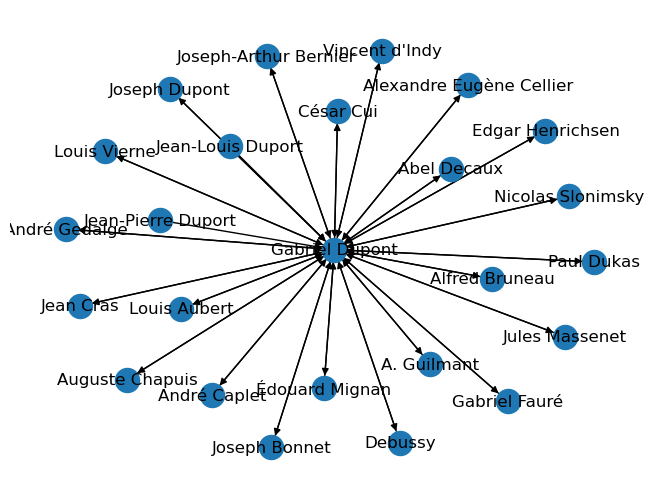

In [7]:
def graph_of_influences(list_of_compo_names):
    list_of_influ_dicts=build_list_of_influences(list_of_compo_names,True)#put false if you're only interested in the english wiki
    adj_list = orienting_with_dates(list_of_influ_dicts)
    return build_graph_from_adj_list(adj_list)
#G=graph_of_influences(["Henri Duparc","John Dunstable"])
G=graph_of_influences(["Gabriel Dupont"])
nx.draw(G, with_labels=True)#, labels = nx.get_node_attributes(graph, 'nom complet'))
    